[![Roboflow Notebooks](https://media.roboflow.com/notebooks/template/bannertest2-2.png?ik-sdk-version=javascript-1.4.3&updatedAt=1672932710194)](https://github.com/roboflow/notebooks)

# How to Train RT-DETR on Custom Dataset

---

[![arXiv](https://img.shields.io/badge/arXiv-2304.08069-b31b1b.svg)](https://arxiv.org/pdf/2304.08069.pdf)
[![GitHub](https://badges.aleen42.com/src/github.svg)](https://github.com/lyuwenyu/RT-DETR)

RT-DETR, short for "Real-Time DEtection TRansformer", is a computer vision model developed by Peking University and Baidu. In their paper, "DETRs Beat YOLOs on Real-time Object Detection" the authors claim that RT-DETR can outperform YOLO models in object detection, both in terms of speed and accuracy. The model has been released under the Apache 2.0 license, making it a great option, especially for enterprise projects.

![RT-DETR Figure.1](https://storage.googleapis.com/com-roboflow-marketing/notebooks/examples/rt-detr-figure-1.png)

Recently, RT-DETR was added to the `transformers` library, significantly simplifying its fine-tuning process. In this tutorial, we will show you how to train RT-DETR on a custom dataset.

## Setup

### Configure your API keys

To fine-tune RT-DETR, you need to provide your HuggingFace Token and Roboflow API key. Follow these steps:

- Open your [`HuggingFace Settings`](https://huggingface.co/settings) page. Click `Access Tokens` then `New Token` to generate new token.
- Go to your [`Roboflow Settings`](https://app.roboflow.com/settings/api) page. Click `Copy`. This will place your private key in the clipboard.
- In Colab, go to the left pane and click on `Secrets` (🔑).
    - Store HuggingFace Access Token under the name `HF_TOKEN`.
    - Store Roboflow API Key under the name `ROBOFLOW_API_KEY`.

### Select the runtime

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `L4 GPU`, and then click `Save`.

In [1]:
!nvidia-smi

Thu Aug  7 08:44:40 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX 3500 Ada Gene...    On  |   00000000:01:00.0 Off |                  Off |
| N/A   38C    P8              5W /   60W |      82MiB /  12282MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

**NOTE:** To make it easier for us to manage datasets, images and models we create a `HOME` constant.

In [2]:
import os
HOME = os.getcwd()
print("HOME:", HOME)

HOME: /home/user/projects/scratchpad/object_detection


### Install dependencies

In [3]:
# !pip install -q git+https://github.com/huggingface/transformers.git
# !pip install -q git+https://github.com/roboflow/supervision.git
# !pip install -q accelerate
# !pip install -q roboflow
# !pip install -q torchmetrics
# !pip install -q "albumentations>=1.4.5"
# !pip install -q python-dotenv

### Imports

In [4]:
import torch
import requests
import os

import numpy as np
import supervision as sv
import albumentations as A

from PIL import Image
from pprint import pprint
from roboflow import Roboflow
from dataclasses import dataclass, replace
from dotenv import load_dotenv
# from google.colab import userdata
from torch.utils.data import Dataset
from transformers import (
    AutoImageProcessor,
    AutoModelForObjectDetection,
    TrainingArguments,
    Trainer
)
from torchmetrics.detection.mean_ap import MeanAveragePrecision

## Inference with pre-trained RT-DETR model

In [5]:
# @title Load model

CHECKPOINT = "PekingU/rtdetr_r50vd_coco_o365"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AutoModelForObjectDetection.from_pretrained(CHECKPOINT).to(DEVICE)
processor = AutoImageProcessor.from_pretrained(CHECKPOINT)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


In [6]:
# @title Run inference

URL = "https://media.roboflow.com/notebooks/examples/dog.jpeg"

image = Image.open(requests.get(URL, stream=True).raw)
inputs = processor(image, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

w, h = image.size
results = processor.post_process_object_detection(
    outputs, target_sizes=[(h, w)], threshold=0.3)

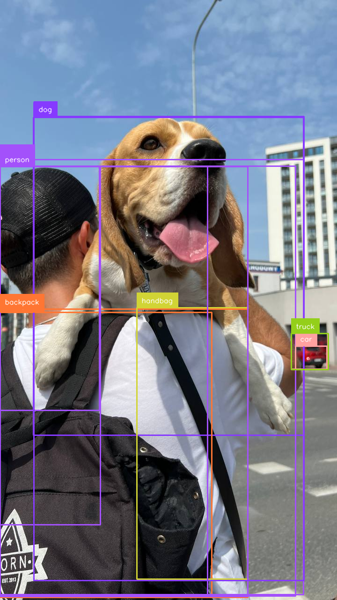

In [7]:
# @title Display result with NMS

detections = sv.Detections.from_transformers(results[0])
labels = [
    model.config.id2label[class_id]
    for class_id
    in detections.class_id
]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels=labels)
annotated_image.thumbnail((600, 600))
annotated_image

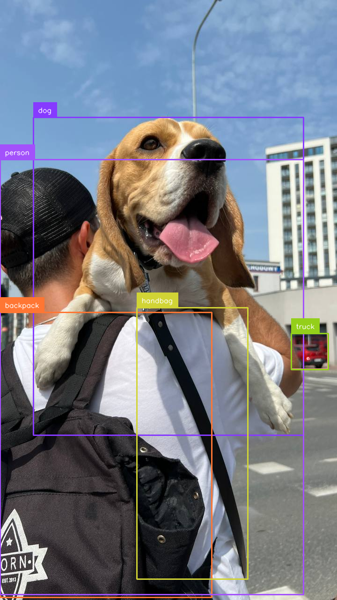

In [8]:
# @title Display result with NMS

detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)
labels = [
    model.config.id2label[class_id]
    for class_id
    in detections.class_id
]

annotated_image = image.copy()
annotated_image = sv.BoxAnnotator().annotate(annotated_image, detections)
annotated_image = sv.LabelAnnotator().annotate(annotated_image, detections, labels=labels)
annotated_image.thumbnail((600, 600))
annotated_image

## Fine-tune RT-DETR on custom dataset

In [9]:
# @title Download dataset from Roboflow Universe

# Load environment variables from .env file
load_dotenv()

ROBOFLOW_API_KEY = os.getenv('ROBOFLOW_API_KEY')
if not ROBOFLOW_API_KEY:
    raise ValueError("ROBOFLOW_API_KEY not found in environment variables. Please check your .env file.")

rf = Roboflow(api_key=ROBOFLOW_API_KEY)

project = rf.workspace("test-0dgvp").project("rust-rt3ec")
version = project.version(1)
dataset = version.download("coco")

loading Roboflow workspace...
loading Roboflow project...


In [10]:
ds_train = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/train",
    annotations_path=f"{dataset.location}/train/_annotations.coco.json",
)
ds_valid = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/valid",
    annotations_path=f"{dataset.location}/valid/_annotations.coco.json",
)
ds_test = sv.DetectionDataset.from_coco(
    images_directory_path=f"{dataset.location}/test",
    annotations_path=f"{dataset.location}/test/_annotations.coco.json",
)

print(f"Number of training images: {len(ds_train)}")
print(f"Number of validation images: {len(ds_valid)}")
print(f"Number of test images: {len(ds_test)}")

Number of training images: 4183
Number of validation images: 782
Number of test images: 259


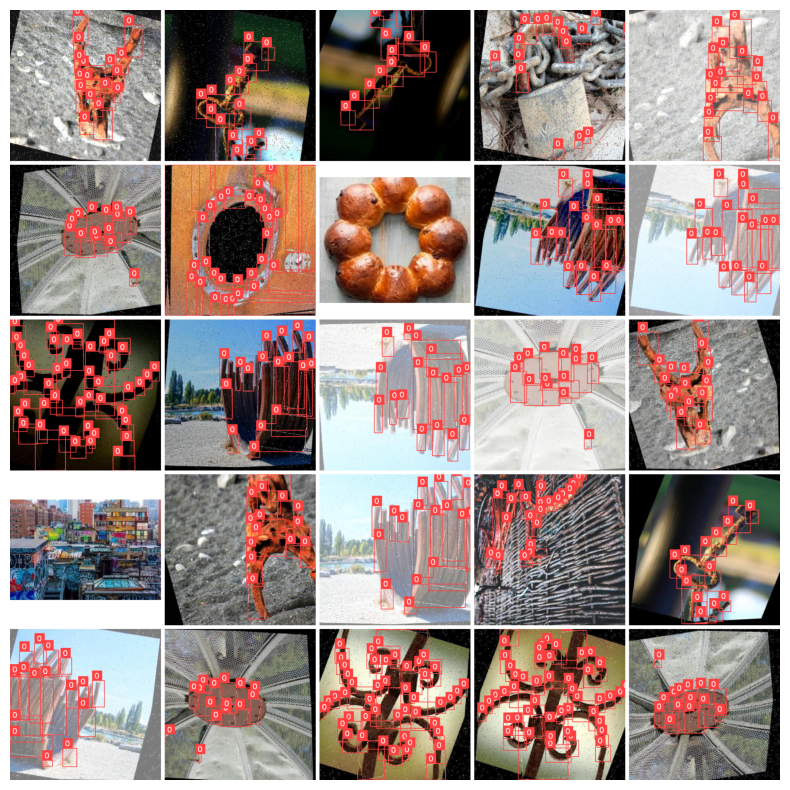

In [11]:
# @title Display dataset sample

GRID_SIZE = 5

def annotate(image, annotations, classes):
    labels = [
        classes[class_id]
        for class_id
        in annotations.class_id
    ]

    bounding_box_annotator = sv.BoxAnnotator()
    label_annotator = sv.LabelAnnotator(text_scale=1, text_thickness=2)

    annotated_image = image.copy()
    annotated_image = bounding_box_annotator.annotate(annotated_image, annotations)
    annotated_image = label_annotator.annotate(annotated_image, annotations, labels=labels)
    return annotated_image

annotated_images = []
for i in range(GRID_SIZE * GRID_SIZE):
    _, image, annotations = ds_train[i]
    annotated_image = annotate(image, annotations, ds_train.classes)
    annotated_images.append(annotated_image)

grid = sv.create_tiles(
    annotated_images,
    grid_size=(GRID_SIZE, GRID_SIZE),
    single_tile_size=(400, 400),
    tile_padding_color=sv.Color.WHITE,
    tile_margin_color=sv.Color.WHITE
)
sv.plot_image(grid, size=(10, 10))

### Preprocess the data

To finetune a model, you must preprocess the data you plan to use to match precisely the approach used for the pre-trained model. [AutoImageProcessor](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoImageProcessor) takes care of processing image data to create `pixel_values`, `pixel_mask`, and `labels` that a DETR model can train with. The image processor has some attributes that you won't have to worry about:

- `image_mean = [0.485, 0.456, 0.406 ]`
- `image_std = [0.229, 0.224, 0.225]`

These are the mean and standard deviation used to normalize images during the model pre-training. These values are crucial to replicate when doing inference or finetuning a pre-trained image model.

Instantiate the image processor from the same checkpoint as the model you want to finetune.

In [12]:
IMAGE_SIZE = 480

processor = AutoImageProcessor.from_pretrained(
    CHECKPOINT,
    do_resize=True,
    size={"width": IMAGE_SIZE, "height": IMAGE_SIZE},
)

Before passing the images to the `processor`, apply two preprocessing transformations to the dataset:

- Augmenting images
- Reformatting annotations to meet RT-DETR expectations

First, to make sure the model does not overfit on the training data, you can apply image augmentation with any data augmentation library. Here we use [Albumentations](https://albumentations.ai/docs/). This library ensures that transformations affect the image and update the bounding boxes accordingly.

In [13]:
train_augmentation_and_transform = A.Compose(
    [
        A.Perspective(p=0.1),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.5),
        A.HueSaturationValue(p=0.1),
    ],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=25,
        min_visibility=0.3  # Ensure at least 30% of the box is visible after transformation
    ),
)

valid_transform = A.Compose(
    [A.NoOp()],
    bbox_params=A.BboxParams(
        format="pascal_voc",
        label_fields=["category"],
        clip=True,
        min_area=1,
        min_visibility=0.1  # Minimal visibility requirement for validation
    ),
)

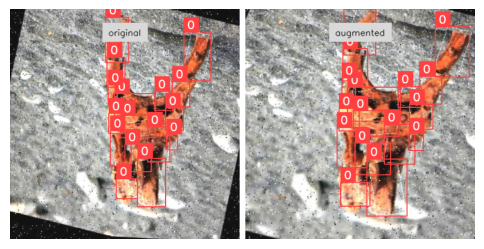

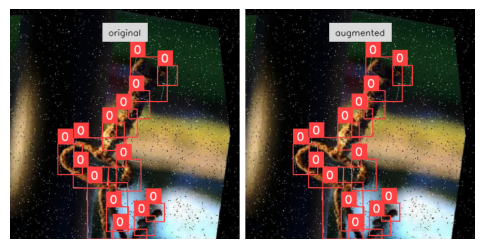

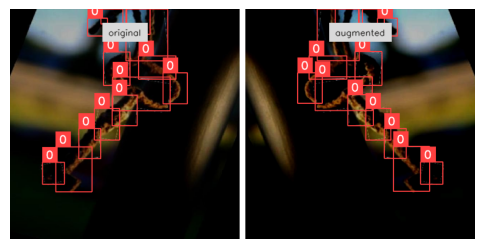

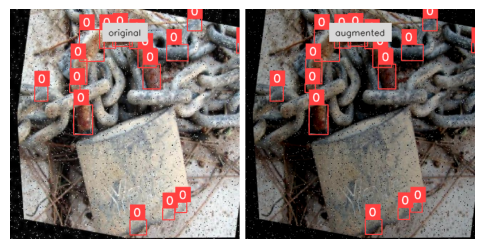

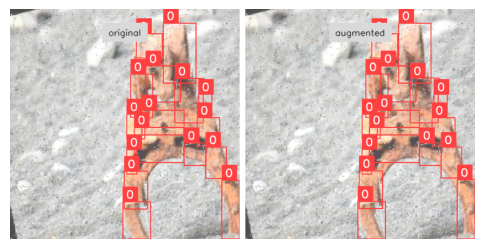

In [14]:
# @title Visualize some augmented images

IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    _, image, annotations = ds_train[i]

    output = train_augmentation_and_transform(
        image=image,
        bboxes=annotations.xyxy,
        category=annotations.class_id
    )

    augmented_image = output["image"]
    augmented_annotations = replace(
        annotations,
        xyxy=np.array(output["bboxes"]),
        class_id=np.array(output["category"])
    )

    annotated_images = [
        annotate(image, annotations, ds_train.classes),
        annotate(augmented_image, augmented_annotations, ds_train.classes)
    ]
    grid = sv.create_tiles(
        annotated_images,
        titles=['original', 'augmented'],
        titles_scale=0.5,
        single_tile_size=(400, 400),
        tile_padding_color=sv.Color.WHITE,
        tile_margin_color=sv.Color.WHITE
    )
    sv.plot_image(grid, size=(6, 6))

The `processor` expects the annotations to be in the following format: `{'image_id': int, 'annotations': List[Dict]}`, where each dictionary is a COCO object annotation. Let's add a function to reformat annotations for a single example:

In [ ]:
class PyTorchDetectionDataset(Dataset):
    def __init__(self, dataset: sv.DetectionDataset, processor, transform: A.Compose = None):
        self.dataset = dataset
        self.processor = processor
        self.transform = transform

    @staticmethod
    def annotations_as_coco(image_id, categories, boxes):
        annotations = []
        for category, bbox in zip(categories, boxes):
            x1, y1, x2, y2 = bbox
            formatted_annotation = {
                "image_id": image_id,
                "category_id": category,
                "bbox": [x1, y1, x2 - x1, y2 - y1],
                "iscrowd": 0,
                "area": (x2 - x1) * (y2 - y1),
            }
            annotations.append(formatted_annotation)

        return {
            "image_id": image_id,
            "annotations": annotations,
        }

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        _, image, annotations = self.dataset[idx]

        # Convert image to RGB numpy array
        image = image[:, :, ::-1]
        boxes = annotations.xyxy
        categories = annotations.class_id

        # Filter out invalid bounding boxes (where width or height <= 0)
        valid_boxes_mask = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        
        if not valid_boxes_mask.any():
            # If no valid boxes, create a dummy small box to avoid empty annotation
            print(f"Warning: No valid boxes in image {idx}, creating dummy box")
            boxes = np.array([[0, 0, 10, 10]], dtype=np.float32)
            categories = np.array([0], dtype=np.int64)
        else:
            # Keep only valid boxes and corresponding categories
            boxes = boxes[valid_boxes_mask]
            categories = categories[valid_boxes_mask]

        if self.transform:
            try:
                transformed = self.transform(
                    image=image,
                    bboxes=boxes,
                    category=categories
                )
                image = transformed["image"]
                boxes = transformed["bboxes"]
                categories = transformed["category"]
                
                # Convert back to numpy arrays if they're lists
                if isinstance(boxes, list):
                    boxes = np.array(boxes)
                if isinstance(categories, list):
                    categories = np.array(categories)
                    
                # Additional validation after transformation
                if len(boxes) == 0:
                    print(f"Warning: No boxes after transformation in image {idx}, creating dummy box")
                    boxes = np.array([[0, 0, 10, 10]], dtype=np.float32)
                    categories = np.array([0], dtype=np.int64)
                    
            except Exception as e:
                print(f"Error in transformation for image {idx}: {e}")
                print(f"Original boxes shape: {boxes.shape}, Categories shape: {categories.shape}")
                # Fallback to original boxes if transformation fails
                pass

        formatted_annotations = self.annotations_as_coco(
            image_id=idx, categories=categories, boxes=boxes)
        result = self.processor(
            images=image, annotations=formatted_annotations, return_tensors="pt")

        # Image processor expands batch dimension, lets squeeze it
        result = {k: v[0] for k, v in result.items()}

        return result

Now you can combine the image and annotation transformations to use on a batch of examples:

In [16]:
# Recreate datasets with the updated class
pytorch_dataset_train = PyTorchDetectionDataset(
    ds_train, processor, transform=train_augmentation_and_transform)
pytorch_dataset_valid = PyTorchDetectionDataset(
    ds_valid, processor, transform=valid_transform)
pytorch_dataset_test = PyTorchDetectionDataset(
    ds_test, processor, transform=valid_transform)

# Test a few samples to ensure they work
print("Testing individual samples...")
for i in [0, 15, 100]:  # Include sample 15 which had no boxes
    try:
        sample = pytorch_dataset_train[i]
        labels = sample.get('labels', {})
        boxes = labels.get('boxes', [])
        print(f"Sample {i}: {len(boxes)} boxes")
    except Exception as e:
        print(f"Error in sample {i}: {e}")

pytorch_dataset_train[15]

Testing individual samples...
Sample 0: 16 boxes
Sample 15: 1 boxes
Sample 100: 4 boxes


{'pixel_values': tensor([[[0.6235, 0.6118, 0.5961,  ..., 0.7569, 0.7569, 0.7569],
          [0.6235, 0.6157, 0.6000,  ..., 0.7569, 0.7569, 0.7569],
          [0.6314, 0.6235, 0.6157,  ..., 0.7529, 0.7529, 0.7529],
          ...,
          [0.0039, 0.0549, 0.1333,  ..., 0.2314, 0.1804, 0.1451],
          [0.0000, 0.0549, 0.1373,  ..., 0.2118, 0.2000, 0.1922],
          [0.0000, 0.0549, 0.1373,  ..., 0.2078, 0.2039, 0.2000]],
 
         [[0.4157, 0.4039, 0.3882,  ..., 0.4902, 0.4902, 0.4902],
          [0.4157, 0.4039, 0.3882,  ..., 0.4902, 0.4902, 0.4902],
          [0.4157, 0.4078, 0.3961,  ..., 0.4863, 0.4863, 0.4863],
          ...,
          [0.3333, 0.3725, 0.4431,  ..., 0.2157, 0.1569, 0.1216],
          [0.3020, 0.3490, 0.4314,  ..., 0.2000, 0.1804, 0.1725],
          [0.2941, 0.3451, 0.4275,  ..., 0.1961, 0.1843, 0.1804]],
 
         [[0.3843, 0.3725, 0.3569,  ..., 0.4863, 0.4863, 0.4863],
          [0.3843, 0.3725, 0.3569,  ..., 0.4863, 0.4863, 0.4863],
          [0.3765, 0.368

In [17]:
# Validate the dataset
def validate_dataset(dataset, name, num_samples=10):
    """Validate a dataset by checking a few samples"""
    print(f"Validating {name} dataset...")
    errors = 0
    
    for i in range(min(num_samples, len(dataset))):
        try:
            sample = dataset[i]
            # Check if we have valid labels
            if len(sample.get('labels', {}).get('boxes', [])) == 0:
                print(f"Warning: Sample {i} has no bounding boxes")
            print(f"Sample {i}: OK")
        except Exception as e:
            print(f"Error in sample {i}: {e}")
            errors += 1
    
    print(f"Validation complete. {errors} errors found in {num_samples} samples.")
    return errors == 0

# Validate datasets
validate_dataset(pytorch_dataset_train, "Training", 20)
validate_dataset(pytorch_dataset_valid, "Validation", 10)

Validating Training dataset...
Sample 0: OK
Sample 1: OK
Sample 2: OK
Sample 3: OK
Sample 4: OK
Sample 5: OK
Sample 6: OK
Sample 7: OK
Sample 8: OK
Sample 9: OK
Sample 10: OK
Sample 11: OK
Sample 12: OK
Sample 13: OK
Sample 14: OK
Sample 15: OK
Sample 16: OK
Sample 17: OK
Sample 18: OK
Sample 19: OK
Validation complete. 0 errors found in 20 samples.
Validating Validation dataset...
Sample 0: OK
Sample 1: OK
Sample 2: OK
Sample 3: OK
Sample 4: OK
Sample 5: OK
Sample 6: OK
Sample 7: OK
Sample 8: OK
Sample 9: OK
Validation complete. 0 errors found in 10 samples.


True

You have successfully augmented the images and prepared their annotations. In the final step, create a custom collate_fn to batch images together.

In [18]:
def collate_fn(batch):
    data = {}
    data["pixel_values"] = torch.stack([x["pixel_values"] for x in batch])
    data["labels"] = [x["labels"] for x in batch]
    return data

## Preparing function to compute mAP

In [19]:
id2label = {id: label for id, label in enumerate(ds_train.classes)}
label2id = {label: id for id, label in enumerate(ds_train.classes)}


@dataclass
class ModelOutput:
    logits: torch.Tensor
    pred_boxes: torch.Tensor


class MAPEvaluator:

    def __init__(self, image_processor, threshold=0.00, id2label=None):
        self.image_processor = image_processor
        self.threshold = threshold
        self.id2label = id2label

    def collect_image_sizes(self, targets):
        """Collect image sizes across the dataset as list of tensors with shape [batch_size, 2]."""
        image_sizes = []
        for batch in targets:
            batch_image_sizes = torch.tensor(np.array([x["size"] for x in batch]))
            image_sizes.append(batch_image_sizes)
        return image_sizes

    def collect_targets(self, targets, image_sizes):
        post_processed_targets = []
        for target_batch, image_size_batch in zip(targets, image_sizes):
            for target, (height, width) in zip(target_batch, image_size_batch):
                boxes = target["boxes"]
                boxes = sv.xcycwh_to_xyxy(boxes)
                boxes = boxes * np.array([width, height, width, height])
                boxes = torch.tensor(boxes)
                labels = torch.tensor(target["class_labels"])
                post_processed_targets.append({"boxes": boxes, "labels": labels})
        return post_processed_targets

    def collect_predictions(self, predictions, image_sizes):
        post_processed_predictions = []
        for batch, target_sizes in zip(predictions, image_sizes):
            batch_logits, batch_boxes = batch[1], batch[2]
            output = ModelOutput(logits=torch.tensor(batch_logits), pred_boxes=torch.tensor(batch_boxes))
            post_processed_output = self.image_processor.post_process_object_detection(
                output, threshold=self.threshold, target_sizes=target_sizes
            )
            post_processed_predictions.extend(post_processed_output)
        return post_processed_predictions

    @torch.no_grad()
    def __call__(self, evaluation_results):

        predictions, targets = evaluation_results.predictions, evaluation_results.label_ids

        image_sizes = self.collect_image_sizes(targets)
        post_processed_targets = self.collect_targets(targets, image_sizes)
        post_processed_predictions = self.collect_predictions(predictions, image_sizes)

        evaluator = MeanAveragePrecision(box_format="xyxy", class_metrics=True)
        evaluator.warn_on_many_detections = False
        evaluator.update(post_processed_predictions, post_processed_targets)

        metrics = evaluator.compute()

        # Replace list of per class metrics with separate metric for each class
        classes = metrics.pop("classes")
        map_per_class = metrics.pop("map_per_class")
        mar_100_per_class = metrics.pop("mar_100_per_class")
        for class_id, class_map, class_mar in zip(classes, map_per_class, mar_100_per_class):
            class_name = id2label[class_id.item()] if id2label is not None else class_id.item()
            metrics[f"map_{class_name}"] = class_map
            metrics[f"mar_100_{class_name}"] = class_mar

        metrics = {k: round(v.item(), 4) for k, v in metrics.items()}

        return metrics

eval_compute_metrics_fn = MAPEvaluator(image_processor=processor, threshold=0.01, id2label=id2label)

## Training the detection model

You have done most of the heavy lifting in the previous sections, so now you are ready to train your model! The images in this dataset are still quite large, even after resizing. This means that finetuning this model will require at least one GPU.

Training involves the following steps:

- Load the model with [`AutoModelForObjectDetection`](https://huggingface.co/docs/transformers/main/en/model_doc/auto#transformers.AutoModelForObjectDetection) using the same checkpoint as in the preprocessing.
- Define your training hyperparameters in [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments).
- Pass the training arguments to [`Trainer`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer) along with the model, dataset, image processor, and data collator.
- Call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train) to finetune your model.

When loading the model from the same checkpoint that you used for the preprocessing, remember to pass the `label2id` and `id2label` maps that you created earlier from the dataset's metadata. Additionally, we specify `ignore_mismatched_sizes=True` to replace the existing classification head with a new one.

In [20]:
model = AutoModelForObjectDetection.from_pretrained(
    CHECKPOINT,
    id2label=id2label,
    label2id=label2id,
    anchor_image_size=None,
    ignore_mismatched_sizes=True,
)

Some weights of RTDetrForObjectDetection were not initialized from the model checkpoint at PekingU/rtdetr_r50vd_coco_o365 and are newly initialized because the shapes did not match:
- model.decoder.class_embed.0.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([2]) in the model instantiated
- model.decoder.class_embed.0.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
- model.decoder.class_embed.1.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([2]) in the model instantiated
- model.decoder.class_embed.1.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
- model.decoder.class_embed.2.bias: found shape torch.Size([80]) in the checkpoint and torch.Size([2]) in the model instantiated
- model.decoder.class_embed.2.weight: found shape torch.Size([80, 256]) in the checkpoint and torch.Size([2, 256]) in the model instantiated
- model.

In the [`TrainingArguments`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.TrainingArguments) use `output_dir` to specify where to save your model, then configure hyperparameters as you see fit. For `num_train_epochs=10` training will take about 15 minutes in Google Colab T4 GPU, increase the number of epoch to get better results.

Important notes:

- Do not remove unused columns because this will drop the image column. Without the image column, you can't create `pixel_values`. For this reason, set `remove_unused_columns` to `False`.
- Set `eval_do_concat_batches=False` to get proper evaluation results. Images have different number of target boxes, if batches are concatenated we will not be able to determine which boxes belongs to particular image.

In [21]:
training_args = TrainingArguments(
    output_dir=f"{dataset.name.replace(' ', '-')}-finetune",
    num_train_epochs=20,
    max_grad_norm=0.1,
    learning_rate=5e-5,
    warmup_steps=300,
    per_device_train_batch_size=12,  # Reduced batch size to be safer
    dataloader_num_workers=2,  # Use single process to avoid multiprocessing issues
    metric_for_best_model="eval_map",
    greater_is_better=True,
    load_best_model_at_end=True,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    remove_unused_columns=False,
    eval_do_concat_batches=False,
    logging_steps=50,  # Add logging to monitor progress
)

Finally, bring everything together, and call [`train()`](https://huggingface.co/docs/transformers/main/en/main_classes/trainer#transformers.Trainer.train):

In [22]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=pytorch_dataset_train,
    eval_dataset=pytorch_dataset_valid,
    tokenizer=processor,
    data_collator=collate_fn,
    compute_metrics=eval_compute_metrics_fn,
)

trainer.train()

`tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.


Epoch,Training Loss,Validation Loss,Map,Map 50,Map 75,Map Small,Map Medium,Map Large,Mar 1,Mar 10,Mar 100,Mar Small,Mar Medium,Mar Large,Map Rusting,Mar 100 Rusting,Map 0,Mar 100 0
1,19.107700,12.956798,0.161300,0.228600,0.178100,0.071400,0.399600,0.403900,0.021700,0.133200,0.225000,0.120100,0.514100,0.635900,0.000000,0.000000,0.322600,0.450000
2,16.064400,11.398211,0.189500,0.270800,0.207000,0.097800,0.454400,0.477600,0.023800,0.148600,0.247000,0.140400,0.561600,0.674600,0.000000,0.000000,0.379000,0.493900
3,15.190900,10.988153,0.204800,0.288000,0.221500,0.109500,0.486800,0.529900,0.025500,0.154700,0.256700,0.144100,0.578300,0.715500,0.000000,0.002300,0.409600,0.511200
4,14.473400,10.696874,0.204300,0.285700,0.221600,0.107300,0.483100,0.530600,0.038600,0.171400,0.276200,0.169800,0.579800,0.699000,0.000000,0.038600,0.408500,0.513800
5,14.012600,10.742532,0.210800,0.300400,0.224400,0.114400,0.491200,0.567200,0.041100,0.174300,0.270500,0.156500,0.581200,0.713800,0.000200,0.029500,0.421500,0.511500
6,13.737000,10.374579,0.222800,0.314900,0.238300,0.125000,0.513500,0.592800,0.077900,0.255400,0.356900,0.240400,0.601400,0.743900,0.002400,0.181800,0.443200,0.532000
7,13.136400,10.318328,0.221200,0.315600,0.238700,0.121200,0.511400,0.593000,0.098000,0.248500,0.355500,0.238400,0.607400,0.752900,0.002000,0.172700,0.440400,0.538300
8,13.249400,9.972178,0.227800,0.325400,0.244000,0.127700,0.519900,0.621500,0.035100,0.299800,0.445300,0.331400,0.615300,0.753800,0.000300,0.343200,0.455200,0.547400
9,12.990900,10.227287,0.221700,0.317700,0.237200,0.123700,0.508100,0.613600,0.042000,0.225800,0.430200,0.310700,0.609000,0.763100,0.000200,0.320500,0.443300,0.539900
10,12.305100,9.902360,0.228800,0.329400,0.245800,0.125600,0.526200,0.621500,0.051500,0.206700,0.424200,0.308400,0.618500,0.764800,0.000500,0.297700,0.457100,0.550700


There were missing keys in the checkpoint model loaded: ['class_embed.0.weight', 'class_embed.0.bias', 'class_embed.1.weight', 'class_embed.1.bias', 'class_embed.2.weight', 'class_embed.2.bias', 'class_embed.3.weight', 'class_embed.3.bias', 'class_embed.4.weight', 'class_embed.4.bias', 'class_embed.5.weight', 'class_embed.5.bias', 'bbox_embed.0.layers.0.weight', 'bbox_embed.0.layers.0.bias', 'bbox_embed.0.layers.1.weight', 'bbox_embed.0.layers.1.bias', 'bbox_embed.0.layers.2.weight', 'bbox_embed.0.layers.2.bias', 'bbox_embed.1.layers.0.weight', 'bbox_embed.1.layers.0.bias', 'bbox_embed.1.layers.1.weight', 'bbox_embed.1.layers.1.bias', 'bbox_embed.1.layers.2.weight', 'bbox_embed.1.layers.2.bias', 'bbox_embed.2.layers.0.weight', 'bbox_embed.2.layers.0.bias', 'bbox_embed.2.layers.1.weight', 'bbox_embed.2.layers.1.bias', 'bbox_embed.2.layers.2.weight', 'bbox_embed.2.layers.2.bias', 'bbox_embed.3.layers.0.weight', 'bbox_embed.3.layers.0.bias', 'bbox_embed.3.layers.1.weight', 'bbox_embed.3.l

TrainOutput(global_step=6980, training_loss=14.041730169170565, metrics={'train_runtime': 4552.9529, 'train_samples_per_second': 18.375, 'train_steps_per_second': 1.533, 'total_flos': 1.4825485496752128e+19, 'train_loss': 14.041730169170565, 'epoch': 20.0})

## Evaluate

In [23]:
# @title Collect predictions

targets = []
predictions = []

for i in range(len(ds_test)):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0])

    targets.append(annotations)
    predictions.append(detections)

In [24]:
# @title Calculate mAP
mean_average_precision = sv.MeanAveragePrecision.from_detections(
    predictions=predictions,
    targets=targets,
)

print(f"map50_95: {mean_average_precision.map50_95:.2f}")
print(f"map50: {mean_average_precision.map50:.2f}")
print(f"map75: {mean_average_precision.map75:.2f}")

map50_95: 0.62
map50: 0.80
map75: 0.69


MeanAveragePrecision is deprecated: `MeanAveragePrecision` is deprecated and will be removed in `supervision-0.31.0`. Use `supervision.metrics.mean_average_precision.MeanAveragePrecision` instead. The deprecated implementation provides results that are inconsistent with pycocotools.


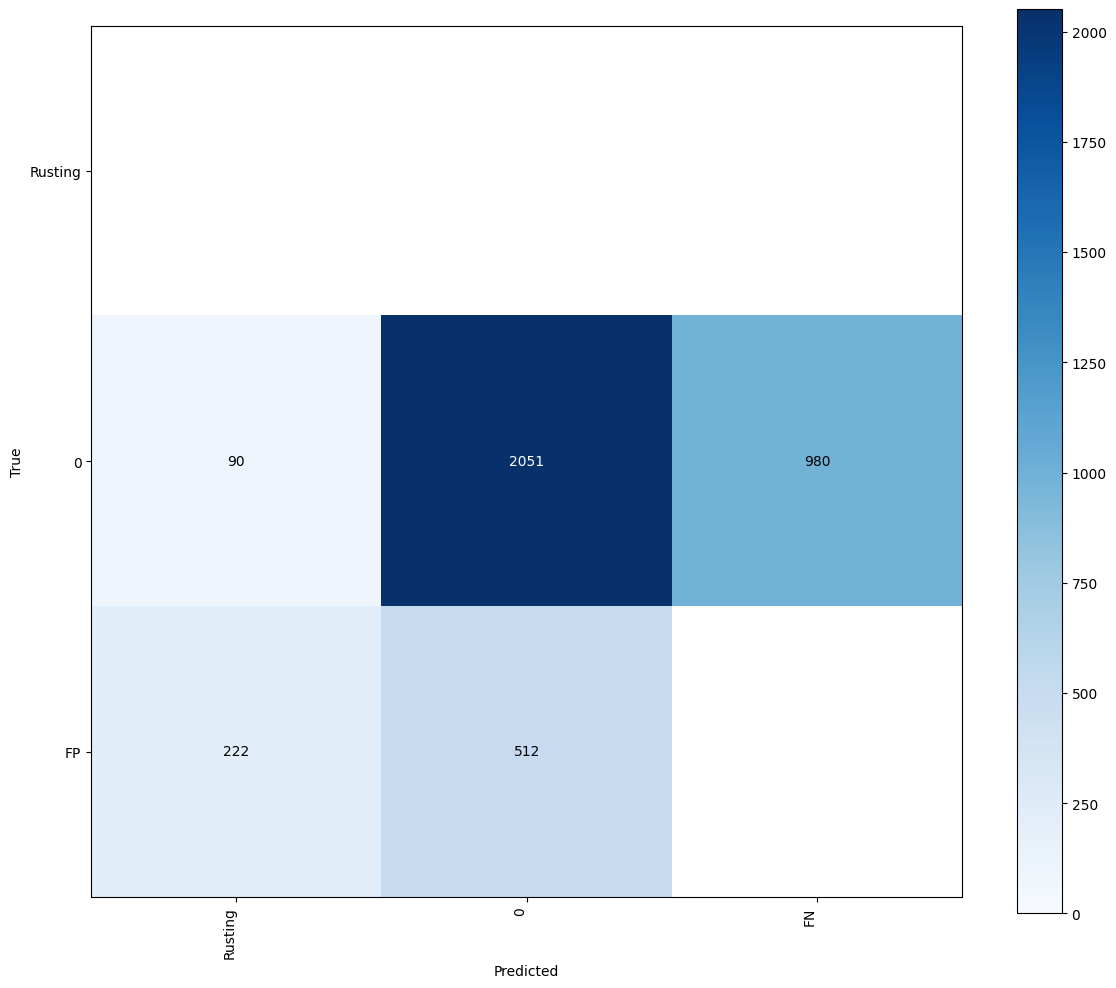

In [25]:
# @title Calculate Confusion Matrix
confusion_matrix = sv.ConfusionMatrix.from_detections(
    predictions=predictions,
    targets=targets,
    classes=ds_test.classes
)

_ = confusion_matrix.plot()

## Save fine-tuned model on hard drive

In [26]:
model.save_pretrained("./rt-detr-rust/")
processor.save_pretrained("./rt-detr-rust/")

['./rt-detr-rust/preprocessor_config.json']

## Inference with fine-tuned RT-DETR model

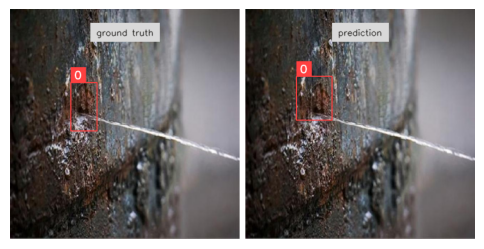

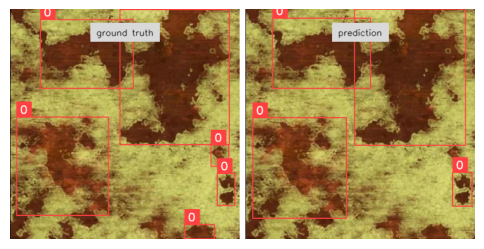

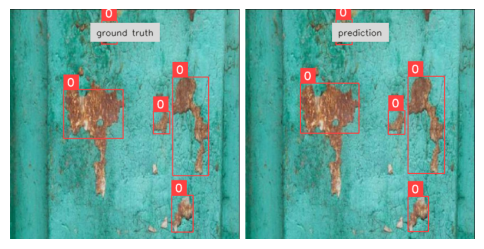

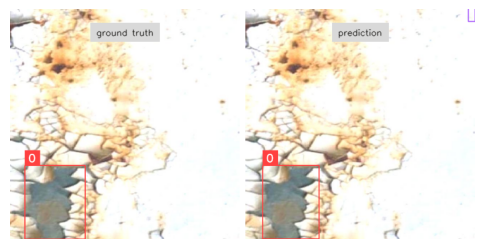

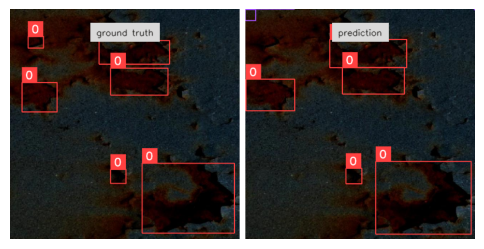

In [27]:
IMAGE_COUNT = 5

for i in range(IMAGE_COUNT):
    path, sourece_image, annotations = ds_test[i]

    image = Image.open(path)
    inputs = processor(image, return_tensors="pt").to(DEVICE)

    with torch.no_grad():
        outputs = model(**inputs)

    w, h = image.size
    results = processor.post_process_object_detection(
        outputs, target_sizes=[(h, w)], threshold=0.3)

    detections = sv.Detections.from_transformers(results[0]).with_nms(threshold=0.1)

    annotated_images = [
        annotate(sourece_image, annotations, ds_train.classes),
        annotate(sourece_image, detections, ds_train.classes)
    ]
    grid = sv.create_tiles(
        annotated_images,
        titles=['ground truth', 'prediction'],
        titles_scale=0.5,
        single_tile_size=(400, 400),
        tile_padding_color=sv.Color.WHITE,
        tile_margin_color=sv.Color.WHITE
    )
    sv.plot_image(grid, size=(6, 6))